Normalization is a technique often applied as a part of data preparation for machine learning . The goal of normalization is to change the values of numeric cols in the dataset to use a common scale , without distorting differences in the ranges of values or losing information .

Basically it is to get rid of  the units of the numeric cols and bring all the cols measuring to a common scale.

normalization can be performed by following methods :-
min max scaling
mean normalization
max absorb
robust scaling


Min max scaling

for a given col of values , xi = xi - xmin/ xmax- xmin

where , xi = the value
        xmax = the greatest value in the col
        xmin = the smallest value in the col


after this , the value of all the elements come between [0,1].

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('wine.csv', header = None , usecols = [0,1,2])
df.columns = ['Class label' , 'Alcohol' , 'Malic acid ']

In [4]:
df.head()


,Class label,Alcohol,Malic acid
0,class,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95


In [5]:
df


,Class label,Alcohol,Malic acid
0,class,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95
...,...,...,...
174,3,13.71,5.65
175,3,13.4,3.91
176,3,13.27,4.28
177,3,13.17,2.59


TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

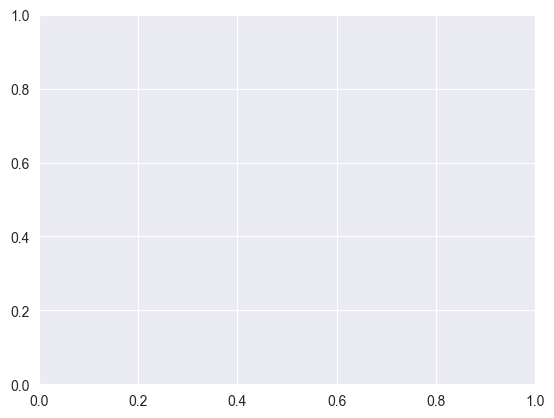

In [6]:
sns.kdeplot(df['Alcohol'] )



In [ ]:
print(df.columns.tolist())


['Class label', 'Alcohol', 'Malic acid ']


In [8]:
df = df[df['Class label'] != 'class']

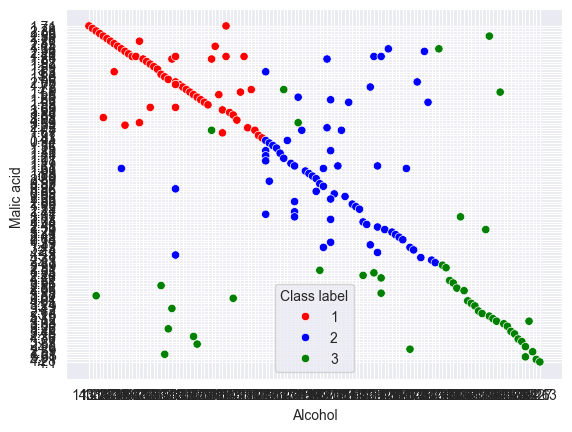

In [9]:
color_dict = {'1':'red', '2':'blue', '3':'green'}
sns.scatterplot(data=df, x='Alcohol', y='Malic acid ', hue='Class label', palette=color_dict)
plt.show()

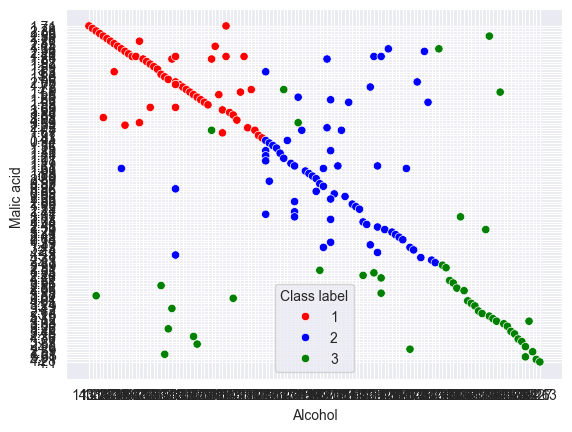

In [10]:
color_dict = {'1': 'red', '2': 'blue', '3': 'green'}
sns.scatterplot(data=df, x='Alcohol', y='Malic acid ', hue='Class label', palette=color_dict)
plt.show()

Train test split

In [11]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop('Class label' , axis = 1) , df['Class label'] , test_size  = 0.3 , random_state = 0 )
x_train.shape , x_test.shape

((124, 2), (54, 2))

scaling

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#fit the scaler to the train set , it will learn parameters
scaler.fit(x_train ,y_train)

#transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [13]:
x_train_scaled = pd.DataFrame(x_train_scaled , columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled , columns = x_test.columns)

In [15]:
x_train.head()


,Alcohol,Malic acid
23,13.71,1.86
109,12.22,1.29
176,13.27,4.28
146,13.16,3.57
72,13.86,1.51


In [16]:
x_train_scaled.head()


,Alcohol,Malic acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252


In [17]:
x_test.head()


,Alcohol,Malic acid
55,13.74,1.67
152,12.79,2.67
64,12.37,1.13
56,13.56,1.73
124,13.05,5.8


In [18]:
x_test_scaled.head()


,Alcohol,Malic acid
0,0.728495,0.163866
1,0.473118,0.373950
2,0.360215,0.050420
3,0.680108,0.176471
4,0.543011,1.031513


In [19]:
y_train.head() #not scaled.


23     1
109    2
176    3
146    3
72     2
Name: Class label, dtype: object

In [20]:
np.round(x_train.describe() , 1)

,Alcohol,Malic acid
count,124,124
unique,97,98
top,12.08,1.73
freq,4,4


In [21]:
np.round(x_train_scaled.describe() , 1) #1 means round to 1 decimal places.

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Before scaling & After scaling distributions

In [33]:
x_train['Alcohol'] = x_train['Alcohol'].astype(float)
x_train['Malic acid '] = x_train['Malic acid '].astype(float)

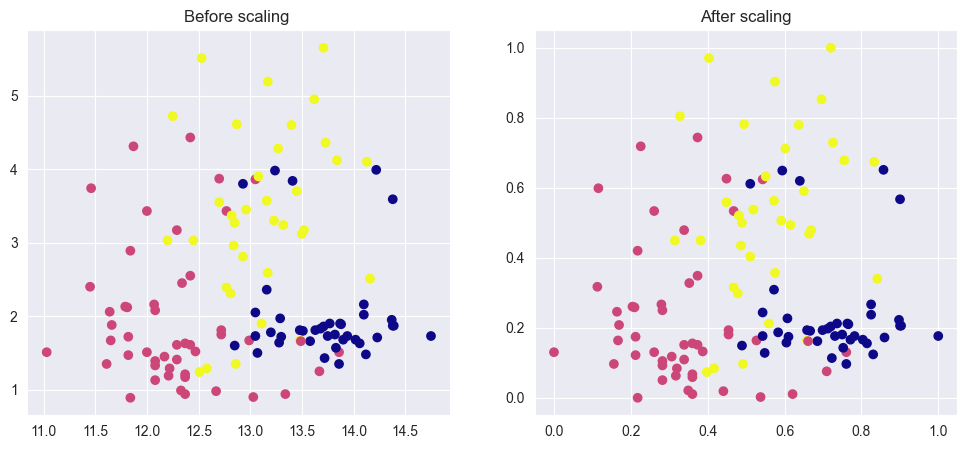

In [34]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2 , figsize = (12, 5))
#2 plots side by side
ax1.scatter(x_train['Alcohol'] , x_train['Malic acid '] , c= y_train.astype(int) , cmap = 'plasma')
ax1.set_title('Before scaling ')
ax2.scatter(x_train_scaled['Alcohol'] , x_train_scaled['Malic acid '] , c = y_train.astype(int) , cmap = 'plasma')
ax2.set_title('After scaling')
plt.show()

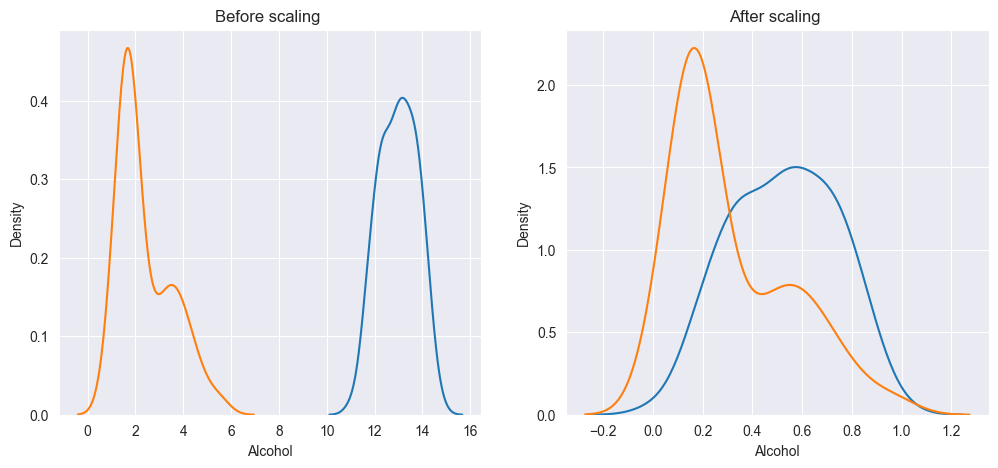

In [38]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2 , figsize=(12, 5))

#before scaling
ax1.set_title('Before scaling ')
sns.kdeplot(x_train['Alcohol'] , ax = ax1)
sns.kdeplot(x_train['Malic acid '] , ax = ax1 )


#after scaling
ax2.set_title('After scaling ')
sns.kdeplot(x_train_scaled['Alcohol'] , ax = ax2)
sns.kdeplot(x_train_scaled['Malic acid '] , ax = ax2)


plt.show()

In [31]:
x_train = x_train.astype(float)


Other normalization techniques

2. Mean normalization
       xi = xi - xmean/ xmax - xmin , values from [-1,1]
       no code available for it in sklearn
3. MaxAbs scaling
     xi = xi/|xmax|   , used when the data has sparse data (many zeros present)  in sklearn, class =MaxAbsScaler
4.Robust scaling
     xi = xi - xmedian/ IQR
where IQR(inter quartile range ) = 75th percentile value - 25th percentile value.
if the data has many outliers , it can be used.


Normalizaton vs Standardization

1. is feature scaling required
2. mostly standardization would be used.
3. minmax